# ModelV1 数据集验证

本 notebook 会从 `modelv1_dataset.csv` 中随机选择一个样本，打印其关键参数，在原图上绘制人脸框和双眼框，显示 resize 后的裁剪图，并在桌面局部坐标系中绘制真实注视点。


In [1]:
from pathlib import Path
import csv
import random
from pprint import pprint

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def find_project_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "data" / "processed" / "modelv1_dataset.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/processed/modelv1_dataset.csv from the current directory.")

PROJECT_ROOT = find_project_root()
CSV_PATH = PROJECT_ROOT / "data" / "processed" / "modelv1_dataset.csv"

with CSV_PATH.open("r", encoding="utf-8-sig", newline="") as f:
    rows = list(csv.DictReader(f))

print("Project root:", PROJECT_ROOT)
print("CSV:", CSV_PATH)
print("Samples:", len(rows))
print("Datasets:", sorted({row["dataset"] for row in rows}))


Project root: D:\GithubCode\ModelV1
CSV: D:\GithubCode\ModelV1\data\processed\modelv1_dataset.csv
Samples: 1133
Datasets: ['dataset_dual_rigid_body_3', 'dataset_dual_rigid_body_4', 'dataset_dual_rigid_body_5']


## 选择一个样本

如果要检查指定的数据采集会话，可将 `DATASET_FILTER` 设置为 `"3"`、`"4"`、`"5"` 或完整数据集名称。保持为 `None` 时，将从全部样本中随机选择。


In [2]:
DATASET_FILTER = None  # examples: "3", "4", "5", "dataset_dual_rigid_body_5"
SAMPLE_INDEX = None    # set an integer to inspect a fixed row; keep None for random
RANDOM_SEED = None     # set an integer for reproducible random sampling

def normalize_dataset_name(value):
    if value is None:
        return None
    text = str(value).strip()
    if text.isdigit():
        return f"dataset_dual_rigid_body_{text}"
    return text

dataset_name = normalize_dataset_name(DATASET_FILTER)
candidates = [row for row in rows if dataset_name is None or row["dataset"] == dataset_name]
if not candidates:
    raise ValueError(f"No rows found for DATASET_FILTER={DATASET_FILTER!r}")

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

if SAMPLE_INDEX is None:
    sample = random.choice(candidates)
else:
    sample = candidates[SAMPLE_INDEX]

pprint({
    "sample_id": sample["sample_id"],
    "dataset": sample["dataset"],
    "image_name": sample["image_name"],
    "frame_idx": sample["frame_idx"],
    "pnp_status": sample["pnp_status"],
})


{'dataset': 'dataset_dual_rigid_body_4',
 'frame_idx': '137',
 'image_name': 'img_20260423_094906_00137.jpg',
 'pnp_status': 'success',
 'sample_id': 'dataset_dual_rigid_body_4/img_20260423_094906_00137'}


## 打印关键参数


In [3]:
def f(row, key):
    value = row.get(key, "")
    return None if value == "" else float(value)

def vector(row, prefix, count):
    return [f(row, f"{prefix}_{idx:02d}") for idx in range(count)]

def bbox(row, prefix):
    return (
        f(row, f"{prefix}_bbox_x"),
        f(row, f"{prefix}_bbox_y"),
        f(row, f"{prefix}_bbox_w"),
        f(row, f"{prefix}_bbox_h"),
    )

crop_cam_vec = vector(sample, "crop_cam", 36)
scene_vec = vector(sample, "scene", 25)

summary = {
    "image paths": {
        "source": sample["source_image_path"],
        "face": sample["face_path"],
        "left_eye": sample["left_eye_path"],
        "right_eye": sample["right_eye_path"],
    },
    "bboxes xywh": {
        "face": bbox(sample, "face"),
        "left_eye": bbox(sample, "left_eye"),
        "right_eye": bbox(sample, "right_eye"),
    },
    "uv_gt_mm": (f(sample, "uv_gt_u_mm"), f(sample, "uv_gt_v_mm")),
    "gaze_target_W_mm": (
        f(sample, "gaze_target_w_x_mm"),
        f(sample, "gaze_target_w_y_mm"),
        f(sample, "gaze_target_w_z_mm"),
    ),
    "table_origin_W_mm": (
        f(sample, "table_origin_w_x_mm"),
        f(sample, "table_origin_w_y_mm"),
        f(sample, "table_origin_w_z_mm"),
    ),
    "gaze_cam_error_mm": f(sample, "gaze_cam_error_mm"),
    "crop_cam_vec_dim": len(crop_cam_vec),
    "scene_vec_dim": len(scene_vec),
}

pprint(summary)

print("\ncrop_cam_vec slices:")
print("  face bbox norm:      ", crop_cam_vec[0:4])
print("  left eye bbox norm:  ", crop_cam_vec[4:8])
print("  right eye bbox norm: ", crop_cam_vec[8:12])
print("  image size norm:     ", crop_cam_vec[12:14])
print("  intrinsics norm:     ", crop_cam_vec[14:18])
print("  face affine:         ", crop_cam_vec[18:24])
print("  left eye affine:     ", crop_cam_vec[24:30])
print("  right eye affine:    ", crop_cam_vec[30:36])

print("\nscene_vec slices:")
print("  n_C:       ", scene_vec[0:3])
print("  d_C:       ", scene_vec[3])
print("  O_table_C: ", scene_vec[4:7])
print("  e1_C:      ", scene_vec[7:10])
print("  e2_C:      ", scene_vec[10:13])
print("  R_CW flat: ", scene_vec[13:22])
print("  t_CW:      ", scene_vec[22:25])


{'bboxes xywh': {'face': (879.0, 186.0, 254.0, 353.0),
                 'left_eye': (1003.0, 300.0, 90.0, 54.0),
                 'right_eye': (884.0, 295.0, 90.0, 54.0)},
 'crop_cam_vec_dim': 36,
 'gaze_cam_error_mm': 81.58643539,
 'gaze_target_W_mm': (-1920.5911, -1023.2451, 4.9409),
 'image paths': {'face': 'D:\\GithubCode\\CrossGaze-main\\baseline\\data_collection\\dataset_dual_rigid_body_4\\insightface_face\\img_20260423_094906_00137.jpg',
                 'left_eye': 'D:\\GithubCode\\CrossGaze-main\\baseline\\data_collection\\dataset_dual_rigid_body_4\\insightface_eyes\\left_eye\\img_20260423_094906_00137.jpg',
                 'right_eye': 'D:\\GithubCode\\CrossGaze-main\\baseline\\data_collection\\dataset_dual_rigid_body_4\\insightface_eyes\\right_eye\\img_20260423_094906_00137.jpg',
                 'source': 'D:\\GithubCode\\CrossGaze-main\\baseline\\data_collection\\dataset_dual_rigid_body_4\\insightface_img\\img_20260423_094906_00137.jpg'},
 'scene_vec_dim': 25,
 'table_ori

## 在原图上显示人脸框和眼睛框

用于检查保存的 bbox 坐标是否仍然与原始图像匹配。


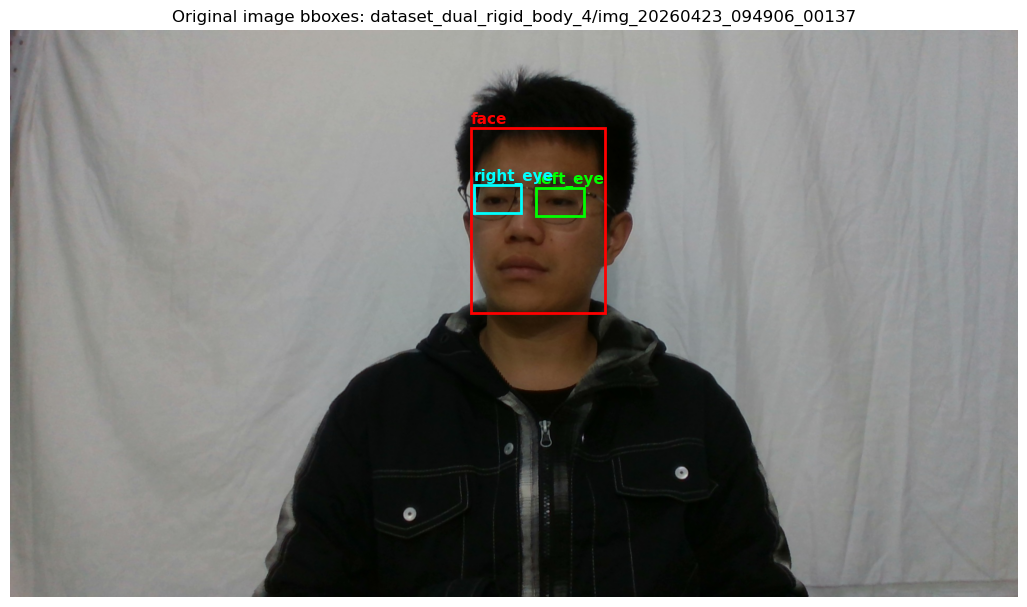

In [4]:
source_path = Path(sample["source_image_path"])
image = Image.open(source_path).convert("RGB")

box_specs = [
    ("face", bbox(sample, "face"), "red"),
    ("left_eye", bbox(sample, "left_eye"), "lime"),
    ("right_eye", bbox(sample, "right_eye"), "cyan"),
]

fig, ax = plt.subplots(figsize=(13, 8))
ax.imshow(image)
for label, (x, y, w, h), color in box_specs:
    rect = Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x, max(0, y - 8), label, color=color, fontsize=11, weight="bold")
ax.set_title(f"Original image bboxes: {sample['sample_id']}")
ax.set_xlim(0, image.width)
ax.set_ylim(image.height, 0)
ax.axis("off")
plt.show()


## 显示 Resize 后的裁剪图

这些是数据预处理流程保存的、实际输入模型的图像。


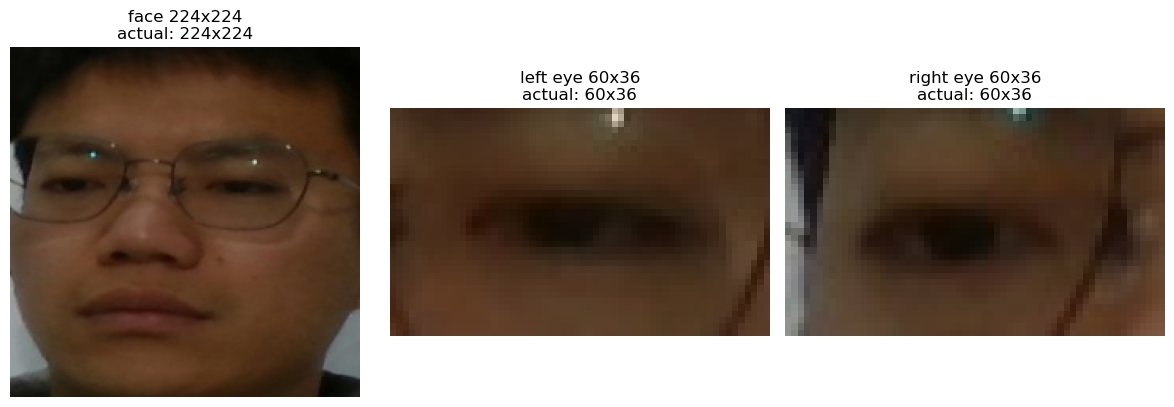

In [5]:
crop_paths = [
    ("face 224x224", Path(sample["face_path"])),
    ("left eye 60x36", Path(sample["left_eye_path"])),
    ("right eye 60x36", Path(sample["right_eye_path"])),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, path) in zip(axes, crop_paths):
    crop = Image.open(path).convert("RGB")
    ax.imshow(crop)
    ax.set_title(f"{title}\nactual: {crop.size[0]}x{crop.size[1]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 仿射变换合理性检查

裁剪仿射变换会将原图坐标映射到 resize 后的裁剪图坐标。bbox 左上角应映射到接近 `(0, 0)` 的位置，bbox 右下角应映射到接近裁剪图尺寸的位置。


In [6]:
def apply_affine(affine, x, y):
    a11, a12, a13, a21, a22, a23 = affine
    return (a11 * x + a12 * y + a13, a21 * x + a22 * y + a23)

affine_specs = [
    ("face", bbox(sample, "face"), crop_cam_vec[18:24], (224, 224)),
    ("left_eye", bbox(sample, "left_eye"), crop_cam_vec[24:30], (60, 36)),
    ("right_eye", bbox(sample, "right_eye"), crop_cam_vec[30:36], (60, 36)),
]

for name, (x, y, w, h), affine, expected_size in affine_specs:
    top_left = apply_affine(affine, x, y)
    bottom_right = apply_affine(affine, x + w, y + h)
    print(name)
    print("  top-left ->", top_left)
    print("  bottom-right ->", bottom_right, "expected", expected_size)


face
  top-left -> (-1.9800040718109813e-08, 9.000004297377018e-09)
  bottom-right -> (223.9999999854, 224.00000000349996) expected (224, 224)
left_eye
  top-left -> (1.000444171950221e-10, 9.999979511121637e-09)
  bottom-right -> (60.00000000310001, 36.00000001179998) expected (60, 36)
right_eye
  top-left -> (6.279992703639437e-08, -2.3500007273469237e-08)
  bottom-right -> (60.000000065799895, 35.99999997829997) expected (60, 36)


## 在桌面局部坐标系中显示真实注视点

图中的原点 `(0, 0)` 是相机光心在桌面上的投影。红点表示所选样本的真实注视目标 `(u, v)`。


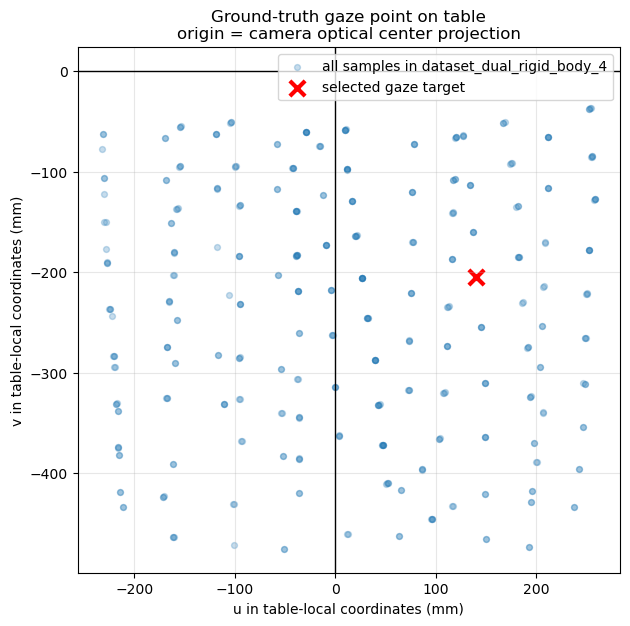

Selected uv_gt_mm: (140.2514636, -205.0161655)
Table origin W mm: (-2060.842564, -818.2289345, 4.214318342)
Gaze target W mm: (-1920.5911, -1023.2451, 4.9409)


In [7]:
same_dataset_rows = [row for row in rows if row["dataset"] == sample["dataset"]]
all_u = [float(row["uv_gt_u_mm"]) for row in same_dataset_rows]
all_v = [float(row["uv_gt_v_mm"]) for row in same_dataset_rows]
u = f(sample, "uv_gt_u_mm")
v = f(sample, "uv_gt_v_mm")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(all_u, all_v, s=18, alpha=0.25, label=f"all samples in {sample['dataset']}")
ax.scatter([u], [v], s=120, color="red", marker="x", linewidths=3, label="selected gaze target")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("u in table-local coordinates (mm)")
ax.set_ylabel("v in table-local coordinates (mm)")
ax.set_title("Ground-truth gaze point on table\norigin = camera optical center projection")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

print("Selected uv_gt_mm:", (u, v))
print("Table origin W mm:", (
    f(sample, "table_origin_w_x_mm"),
    f(sample, "table_origin_w_y_mm"),
    f(sample, "table_origin_w_z_mm"),
))
print("Gaze target W mm:", (
    f(sample, "gaze_target_w_x_mm"),
    f(sample, "gaze_target_w_y_mm"),
    f(sample, "gaze_target_w_z_mm"),
))
